# Student Career & Employability Survey Analysis

# Notebook 02: Exploratory Data Analysis (EDA)

## Objective

The objective of this notebook is to explore the cleaned student survey dataset and uncover meaningful insights related to students' career readiness, technical skills, learning habits, and employability.

Exploratory Data Analysis (EDA) helps transform raw survey responses into actionable information by identifying patterns, trends, and relationships within the data.

The insights generated in this notebook will later be used to build an interactive Power BI dashboard.

---

## EDA Workflow

1. Dataset Overview
2. Student Demographics
3. Skills Analysis
4. Learning Behaviour
5. Career Readiness
6. Job Readiness
7. Career Goals & Challenges
8. Relationship Analysis
9. Key Insights

# Step 1: Import Required Libraries

In this notebook, we will use several Python libraries for data analysis and visualization.

### Libraries Used

- **Pandas** – Data manipulation and analysis
- **NumPy** – Numerical operations
- **Matplotlib** – Data visualization

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Step 2: Load the Cleaned Dataset

The cleaned dataset generated in Notebook 01 is loaded for exploratory analysis.

All data quality issues have already been addressed during the cleaning phase, allowing us to focus entirely on exploring and interpreting the data.

In [3]:
df = pd.read_csv("../Data/cleaned/student_survey_cleaned.csv")

# Step 3: Dataset Overview

Before beginning the analysis, it is important to understand the overall structure of the dataset.

In this section, we examine:

- Number of observations
- Number of variables
- Column names
- Data types
- Sample records

This provides a quick overview of the data available for analysis.

In [4]:
print(f"Number of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")

Number of Rows    : 85
Number of Columns : 26


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85 entries, 0 to 84
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   timestamp                        85 non-null     object
 1   student_type                     85 non-null     object
 2   field_of_study                   85 non-null     object
 3   degree                           85 non-null     object
 4   state                            85 non-null     object
 5   current_skills                   79 non-null     object
 6   learning_skill                   70 non-null     object
 7   technical_confidence             85 non-null     int64 
 8   daily_learning_hours             85 non-null     object
 9   learning_platform                85 non-null     object
 10  professional_certifications      85 non-null     object
 11  certification_count              85 non-null     object
 12  has_resume                       85 no

In [6]:
df.head()

,timestamp,student_type,field_of_study,degree,state,current_skills,learning_skill,technical_confidence,daily_learning_hours,learning_platform,...,job_applications,interview_count,job_confidence,career_goal,expected_salary,biggest_challenge,improvement_area,career_preparation_satisfaction,recommend_learning_approach,additional_comments
0,2026-06-26 13:32:28,Recent Graduate,Commerce,Bachelor's Degree,Telangana,"SQL, Power BI, Python, Java, Web Development, ...","MS Excel, Cloud Computing",4,2–4 hours,YouTube,...,1-20,1-2,3,Data Analyst,₹5–8 LPA,Communication Skills,Communication Skills,3,Yes,Skill development
1,2026-06-26 21:08:55,3rd Year Student,Engineering,Bachelor's Degree,Telangana,"Python, Web Development","Python, Web Development",3,Less than 1 hour,Other,...,1-20,0,3,Web Developer,₹8–12 LPA,Lack of Technical Skills,Technical Skills,2,No,No
2,2026-06-26 21:10:24,3rd Year Student,Engineering,Bachelor's Degree,Telangana,"MS Excel, SQL, Power BI, Python, Web Developme...","MS Excel, SQL, Power BI, Python, Web Developme...",4,1–2 hours,YouTube,...,1-20,3-5,3,Data Analyst,₹8–12 LPA,Limited Job Opportunities,Certifications,3,Maybe,No
3,2026-06-26 21:11:13,3rd Year Student,Engineering,Bachelor's Degree,Andhra Pradesh,"SQL, Python, Java","Web Development, Data Analysis, Ai Tools",3,2–4 hours,YouTube,...,1-20,1-2,1,AI / Machine Learning,Above ₹12 LPA,Communication Skills,Communication Skills,3,Maybe,Suggest some part time jobs for students
4,2026-06-26 21:12:09,2nd Year Student,Engineering,Bachelor's Degree,Telangana,"MS Excel, SQL, Python, C++, Web Development, D...","SQL, Ai Tools",2,Less than 1 hour,YouTube,...,1-20,1-2,3,Other,₹8–12 LPA,Lack of Technical Skills,Technical Skills,2,Maybe,Good Luck On Your Research !


# Section 1: Student Demographics Analysis

## Business Objective

Understanding the demographic profile of survey participants is the first step in any survey analysis.

This section answers the following questions:

- How many students participated in the survey?
- What types of students responded?
- Which degree programs are represented?
- Which fields of study are most common?
- Which states contributed the highest number of responses?

These insights help us understand the composition of the dataset before exploring career readiness and employability trends.

## Business Question 1

### How many students participated in the survey?

The total number of responses provides an overview of the survey size and serves as a key performance indicator (KPI) throughout the analysis.

In [7]:
total_students = len(df)

print(f"Total Survey Responses: {total_students}")

Total Survey Responses: 85


## Business Question 2

### What is the distribution of student types?

This analysis shows the proportion of respondents based on their current academic or professional status.

Understanding the respondent mix helps interpret the remaining survey results in the correct context.

In [8]:
student_type = df["student_type"].value_counts()

student_type

student_type
Recent Graduate         35
Final Year Student      19
3rd Year Student        14
2nd Year Student         7
Working Professional     6
1st Year Student         4
Name: count, dtype: int64

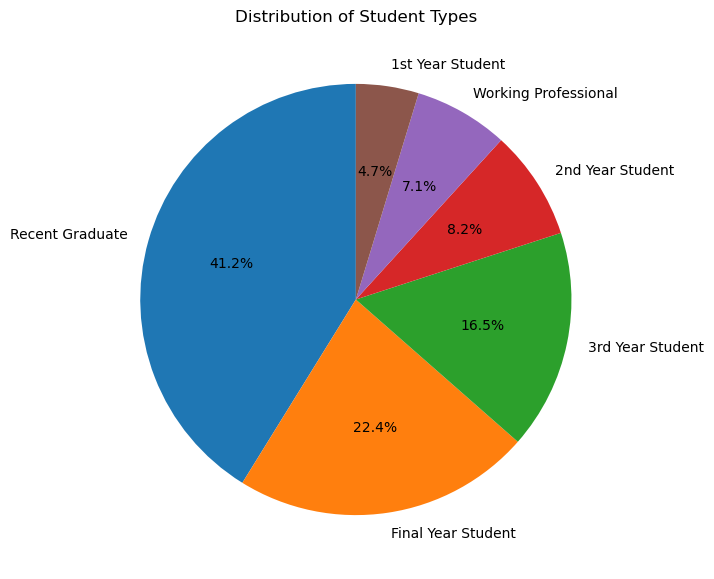

In [9]:
plt.figure(figsize=(7,7))

student_type.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.ylabel("")
plt.title("Distribution of Student Types")

plt.show()

### Key Insights

- A total of **85 respondents** participated in the survey.
- **Recent Graduates (41.2%)** represent the largest respondent group, indicating that the survey primarily captures individuals actively preparing for employment.
- **Final Year Students (22.4%)** and **Third Year Students (16.5%)** together account for a significant share of the responses, highlighting strong participation from students nearing graduation.
- A smaller proportion of responses came from **Working Professionals (7.1%)**, **Second Year Students (8.2%)**, and **First Year Students (4.7%)**.

### Dashboard Recommendation

- Display this analysis using a **Donut Chart** with a KPI card showing the total number of survey responses.

## Business Question 3

### Which degree programs have the highest participation?

This analysis identifies the educational qualifications of the respondents and helps understand the academic diversity within the survey.

In [10]:
degree = df["degree"].value_counts()

degree

degree
Bachelor's Degree    74
Master's Degree       8
Other                 2
Diploma               1
Name: count, dtype: int64

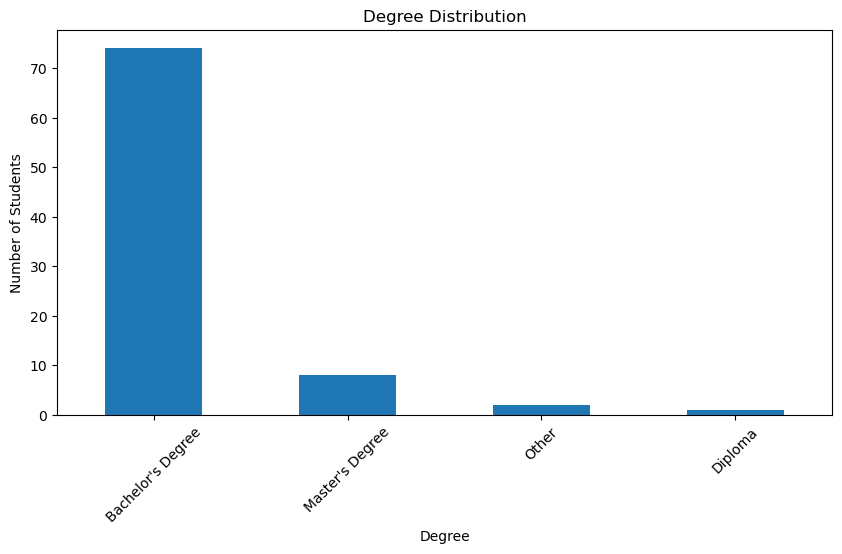

In [11]:
plt.figure(figsize=(10,5))

degree.plot(kind="bar")

plt.title("Degree Distribution")

plt.xlabel("Degree")

plt.ylabel("Number of Students")

plt.xticks(rotation=45)

plt.show()

### Key Insights

- The survey is heavily dominated by **Bachelor's Degree students**, representing the vast majority of respondents.
- Only a small number of participants are pursuing **Master's Degrees**, **Diplomas**, or **Other qualifications**.
- Since undergraduate students form the largest respondent group, subsequent analyses should be interpreted primarily from an undergraduate perspective.

### Dashboard Recommendation

- Visualize the distribution using a **Bar Chart** sorted in descending order.

## Business Question 4

### Which fields of study are most common among the respondents?

This analysis highlights the academic disciplines represented in the survey and provides context for skill and career-related findings.

In [12]:
field = df["field_of_study"].value_counts()

field

field_of_study
Engineering    35
Commerce       26
Science        16
Management      4
Pharmacy        2
Arts            2
Name: count, dtype: int64

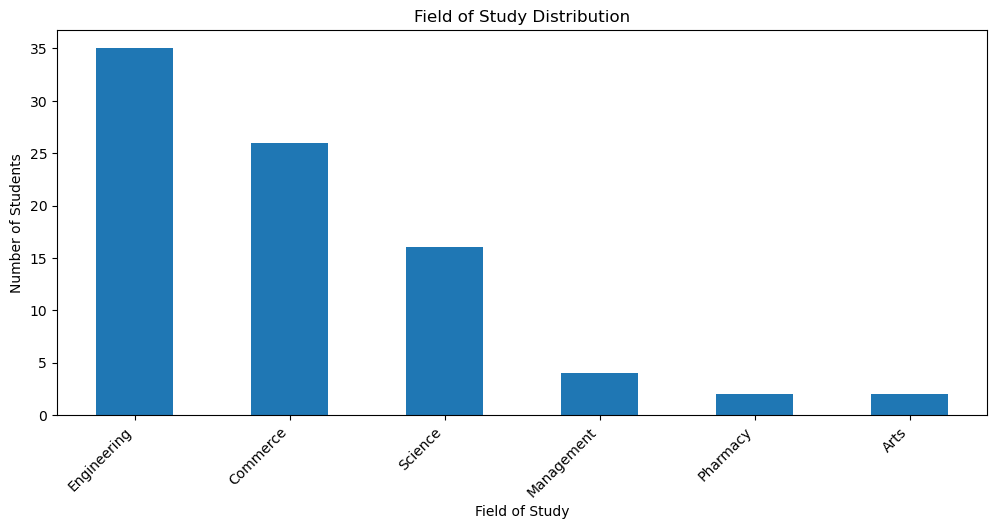

In [13]:
plt.figure(figsize=(12,5))

field.plot(kind="bar")

plt.title("Field of Study Distribution")

plt.xlabel("Field of Study")

plt.ylabel("Number of Students")

plt.xticks(rotation=45, ha="right")

plt.show()

### Key Insights

- **Engineering** students constitute the largest respondent group.
- **Commerce** students represent the second-largest group, followed by **Science** students.
- **Management**, **Pharmacy**, and **Arts** have comparatively lower participation.
- The survey therefore provides stronger insights into the career readiness of Engineering and Commerce students.

### Dashboard Recommendation

- Use a **Horizontal Bar Chart** sorted in descending order for easier comparison across academic disciplines.

## Business Question 5

### Which states are represented in the survey?

This analysis identifies the geographical distribution of respondents and helps determine whether the survey represents multiple regions or is concentrated in specific states.

In [14]:
state = df["state"].value_counts()

state

state
Telangana         61
Haryana            7
Maharashtra        5
Andhra Pradesh     3
Delhi              3
Uttar Pradesh      2
Karnataka          2
West Bengal        1
Jharkhand          1
Name: count, dtype: int64

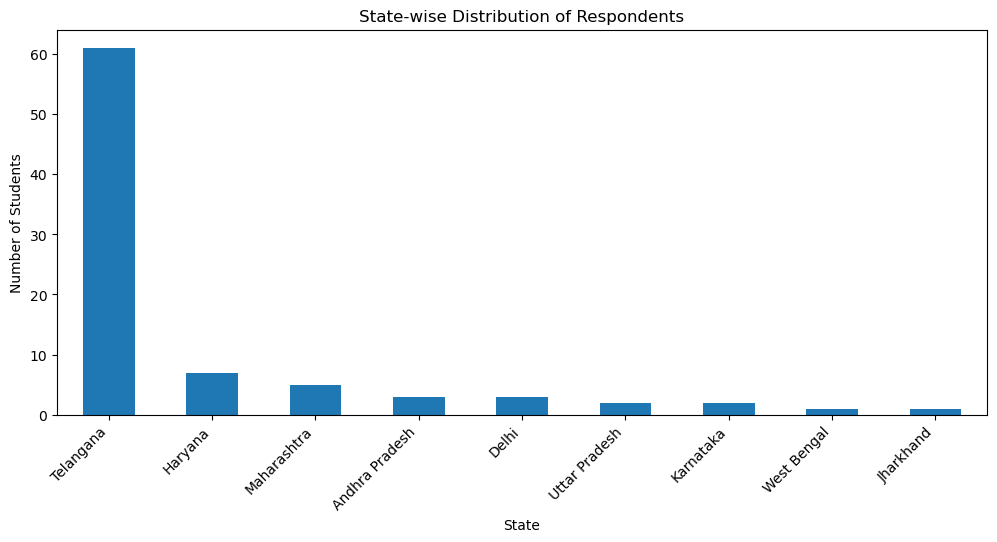

In [15]:
plt.figure(figsize=(12,5))

state.plot(kind="bar")

plt.title("State-wise Distribution of Respondents")

plt.xlabel("State")

plt.ylabel("Number of Students")

plt.xticks(rotation=45, ha="right")

plt.show()

### Key Insights

- The majority of responses were collected from **Telangana**, making it the primary geographical region represented in the survey.
- A smaller number of responses were received from states such as **Haryana**, **Maharashtra**, **Andhra Pradesh**, **Delhi**, **Uttar Pradesh**, **Karnataka**, **West Bengal**, and **Jharkhand**.
- Since the dataset is regionally concentrated, the findings should be interpreted with this geographical distribution in mind.

### Dashboard Recommendation

- Display this analysis using a **Bar Chart** or **Filled Map** in Power BI to highlight the regional distribution of respondents.

## Summary

The demographic analysis provides an overview of the survey participants by examining their academic status, degree programs, fields of study, and geographical distribution.

These findings establish the context for the remaining analyses related to skills, learning behavior, career readiness, and employability.

# Section 2: Skills Analysis

## Business Objective

Technical skills play a crucial role in determining a student's employability and career readiness.

This section analyzes the current technical skills possessed by students, the skills they are actively learning, the platforms they use for learning, and their confidence in their technical abilities.

The objective is to identify the most common skills and understand current learning trends among students.

## Business Question 1

### What technical skills do students currently possess?

This question helps identify the most common technical skills among respondents.

Since students could select multiple skills, each selected skill will be counted individually.

In [16]:
df["current_skills"].value_counts()

current_skills
MS Excel                                                                                    10
MS Excel, SQL, Power BI                                                                      4
MS Excel, SQL, Power BI, Python, Data Analysis, Ai Tools                                     4
MS Excel, SQL                                                                                3
MS Excel, SQL, Power BI, Python                                                              3
SQL, Python, Java                                                                            2
Python, Web Development                                                                      2
MS Excel, Python                                                                             2
MS Excel, Power BI                                                                           2
MS Excel, SQL, Power BI, Data Analysis                                                       2
SQL, Python, Java, Web Development,

In [17]:
df["current_skills"].head(10)

0    SQL, Power BI, Python, Java, Web Development, ...
1                              Python, Web Development
2    MS Excel, SQL, Power BI, Python, Web Developme...
3                                    SQL, Python, Java
4    MS Excel, SQL, Python, C++, Web Development, D...
5               SQL, Python, Web Development, Ai Tools
6    SQL, Python, Java, Web Development, Data Analy...
7                       C++, Web Development, Ai Tools
8    MS Excel, SQL, Power BI, Data Analysis, Digita...
9    MS Excel, SQL, Power BI, Python, Web Developme...
Name: current_skills, dtype: object

In [18]:
df["current_skills"].sample(10, random_state=42)

78                MS Excel, Power BI, Digital Marketing
0     SQL, Power BI, Python, Java, Web Development, ...
68                                     Python, Ai Tools
22                                        MS Excel, SQL
12                              MS Excel, SQL, Power BI
82         Digital Marketing, Ai Tools, Cloud Computing
10                                   MS Excel, Power BI
18                                   MS Excel, Power BI
4     MS Excel, SQL, Python, C++, Web Development, D...
66                                        MS Excel, SQL
Name: current_skills, dtype: object

In [19]:
current_skills = (
    df["current_skills"]
    .str.split(", ")
    .explode()
)

current_skills.head(10)

0                  SQL
0             Power BI
0               Python
0                 Java
0      Web Development
0        Data Analysis
0    Digital Marketing
0             Ai Tools
1               Python
1      Web Development
Name: current_skills, dtype: object

In [20]:
current_skill_count = current_skills.value_counts()

current_skill_count

current_skills
MS Excel             52
SQL                  46
Python               42
Power BI             30
Ai Tools             27
Web Development      25
Data Analysis        24
Java                 14
C++                  10
Digital Marketing     9
Cloud Computing       6
Name: count, dtype: int64

In [21]:
top_current_skills = current_skill_count.head(10)

top_current_skills

current_skills
MS Excel             52
SQL                  46
Python               42
Power BI             30
Ai Tools             27
Web Development      25
Data Analysis        24
Java                 14
C++                  10
Digital Marketing     9
Name: count, dtype: int64

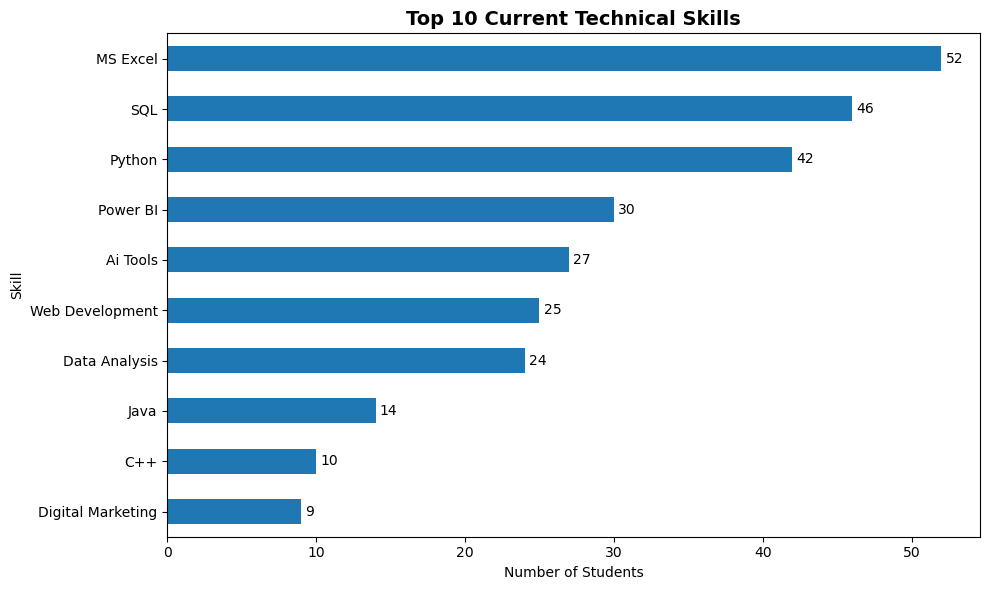

In [24]:
plt.figure(figsize=(10,6))

ax = top_current_skills.sort_values().plot(kind="barh")

plt.title("Top 10 Current Technical Skills", fontsize=14, fontweight="bold")
plt.xlabel("Number of Students")
plt.ylabel("Skill")

# Add value labels
for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()

In [23]:
current_skill_percentage = (
    current_skill_count / len(df) * 100
).round(1)

current_skill_percentage.head(10)

current_skills
MS Excel             61.2
SQL                  54.1
Python               49.4
Power BI             35.3
Ai Tools             31.8
Web Development      29.4
Data Analysis        28.2
Java                 16.5
C++                  11.8
Digital Marketing    10.6
Name: count, dtype: float64

### Key Insights

- **MS Excel** is the most commonly reported technical skill, with **52 students** indicating proficiency.
- **SQL (46)** and **Python (42)** are the next most popular skills, demonstrating a strong interest in data-related technologies.
- **Power BI (30)**, **AI Tools (27)**, and **Data Analysis (24)** also have significant adoption, suggesting that many students are preparing for careers in Data Analytics and Business Intelligence.
- **Web Development (25)** remains a popular technical skill, while **Java (14)** and **C++ (10)** show comparatively lower adoption.
- **Digital Marketing (9)** has the lowest representation among the top ten skills.

### Business Insight

The survey indicates a growing focus on **data-oriented technologies**, with Microsoft Excel, SQL, Python, and Power BI emerging as the dominant skills among students. This suggests an increasing interest in careers related to Data Analytics, Business Intelligence, and Artificial Intelligence.

### Dashboard Recommendation

Display the **Top 10 Current Technical Skills** using a horizontal bar chart sorted in descending order to enable quick comparison between skills.

In [25]:
learning_skills = (
    df["learning_skill"]
    .str.split(", ")
    .explode()
)

In [26]:
learning_skill_count = learning_skills.value_counts()

learning_skill_count

learning_skill
Data Analysis        25
Ai Tools             23
Power BI             22
Cloud Computing      19
Python               19
SQL                  18
MS Excel             15
Web Development      15
Java                  9
Digital Marketing     9
C++                   2
Name: count, dtype: int64

In [27]:
top_learning_skills = learning_skill_count.head(10)

top_learning_skills

learning_skill
Data Analysis        25
Ai Tools             23
Power BI             22
Cloud Computing      19
Python               19
SQL                  18
MS Excel             15
Web Development      15
Java                  9
Digital Marketing     9
Name: count, dtype: int64

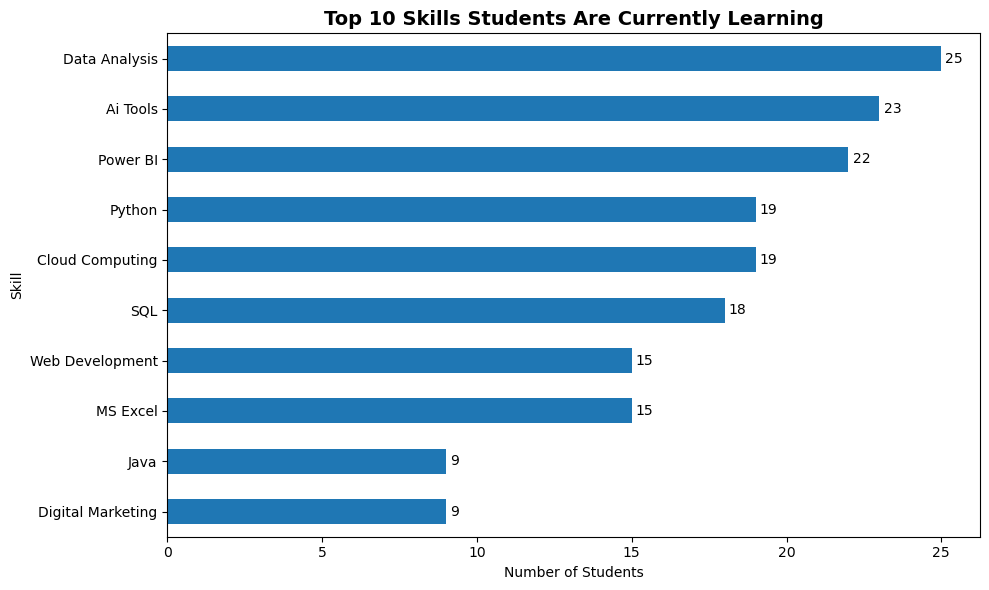

In [28]:
plt.figure(figsize=(10,6))

ax = top_learning_skills.sort_values().plot(kind="barh")

plt.title("Top 10 Skills Students Are Currently Learning", fontsize=14, fontweight="bold")
plt.xlabel("Number of Students")
plt.ylabel("Skill")

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()

## Business Question 3

### Which learning platforms do students use to develop their technical skills?

Students were allowed to select multiple learning platforms in the survey. Therefore, each selected platform will be counted individually.

This analysis helps identify the most preferred learning resources among students and provides insights into current learning trends.

In [29]:
learning_platforms = (
    df["learning_platform"]
    .str.split(", ")
    .explode()
)

learning_platforms.head(10)

0    YouTube
1      Other
2    YouTube
3    YouTube
4    YouTube
5    YouTube
6    YouTube
7    YouTube
8    YouTube
9    YouTube
Name: learning_platform, dtype: object

In [30]:
learning_platform_count = learning_platforms.value_counts()

learning_platform_count

learning_platform
YouTube     68
College      5
Other        3
Coursera     3
Books        3
Udemy        2
Friends      1
Name: count, dtype: int64

In [31]:
top_learning_platforms = learning_platform_count.head(10)

top_learning_platforms

learning_platform
YouTube     68
College      5
Other        3
Coursera     3
Books        3
Udemy        2
Friends      1
Name: count, dtype: int64

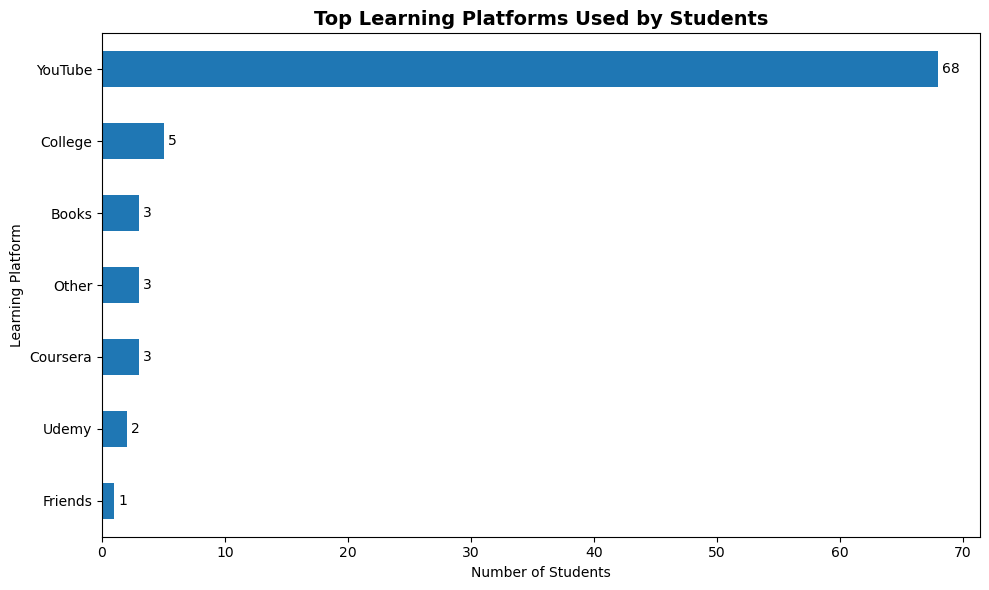

In [32]:
plt.figure(figsize=(10,6))

ax = top_learning_platforms.sort_values().plot(kind="barh")

plt.title("Top Learning Platforms Used by Students", fontsize=14, fontweight="bold")

plt.xlabel("Number of Students")
plt.ylabel("Learning Platform")

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()

plt.show()

In [33]:
platform_percentage = (
    learning_platform_count / len(df) * 100
).round(1)

platform_percentage

learning_platform
YouTube     80.0
College      5.9
Other        3.5
Coursera     3.5
Books        3.5
Udemy        2.4
Friends      1.2
Name: count, dtype: float64

### Key Insights

- The most preferred learning platform among students is YouTube.
- Online video-based learning platforms dominate student preferences.
- Structured learning platforms such as Coursera are also widely used.
- Community-driven platforms have comparatively lower adoption.

### Business Insight

The findings suggest that students prefer flexible and self-paced online learning resources for skill development. Educational institutions and training providers can leverage these preferred platforms to improve student engagement and learning outcomes.

### Dashboard Recommendation

Use a horizontal bar chart sorted in descending order to compare the popularity of different learning platforms.

# Section 3: Learning Behaviour Analysis

## Business Objective

Continuous learning plays a significant role in improving students' technical competencies and career readiness.

This section analyzes students' confidence in their technical skills and their daily learning habits.

The objective is to understand how students perceive their current skill level and the amount of time they dedicate to learning each day.

## Business Question 1

### How confident are students in their technical skills?

Technical confidence reflects how comfortable students feel with their current technical knowledge and abilities.

Understanding confidence levels helps identify whether students feel prepared for internships, projects, and job opportunities.

In [37]:
df["technical_confidence"].value_counts()

technical_confidence
3    35
4    30
5     8
2     7
1     5
Name: count, dtype: int64

In [38]:
df["daily_learning_hours"].value_counts()

daily_learning_hours
1–2 hours            28
2–4 hours            24
Less than 1 hour     17
4–6 hours            13
More than 6 hours     3
Name: count, dtype: int64

In [34]:
technical_confidence = df["technical_confidence"].value_counts()

technical_confidence

technical_confidence
3    35
4    30
5     8
2     7
1     5
Name: count, dtype: int64

In [35]:
technical_confidence_percentage = (
    df["technical_confidence"]
      .value_counts(normalize=True)
      .mul(100)
      .round(1)
)

technical_confidence_percentage

technical_confidence
3    41.2
4    35.3
5     9.4
2     8.2
1     5.9
Name: proportion, dtype: float64

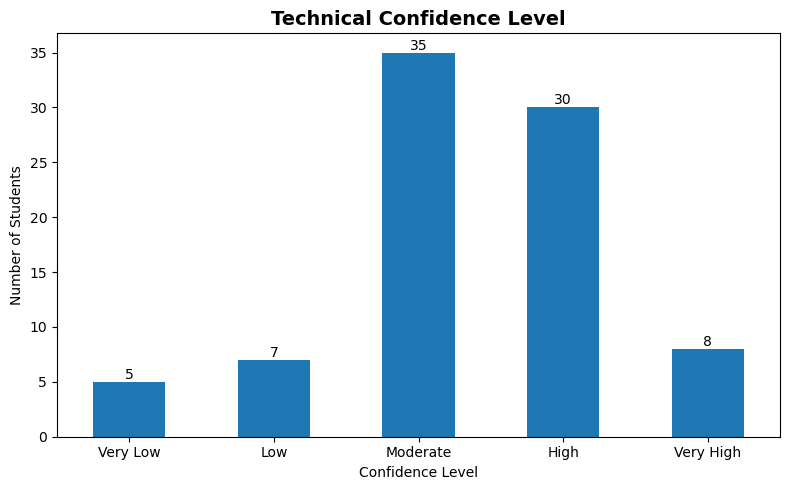

In [39]:
# Define the order
confidence_order = [1, 2, 3, 4, 5]

# Reorder the values
technical_confidence = (
    df["technical_confidence"]
    .value_counts()
    .reindex(confidence_order)
)

plt.figure(figsize=(8,5))

ax = technical_confidence.plot(kind="bar")

plt.title("Technical Confidence Level", fontsize=14, fontweight="bold")
plt.xlabel("Confidence Level")
plt.ylabel("Number of Students")

# Replace numbers with labels
plt.xticks(
    ticks=range(5),
    labels=[
        "Very Low",
        "Low",
        "Moderate",
        "High",
        "Very High"
    ],
    rotation=0
)

# Add value labels
for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

### Key Insights

- The majority of students rated their technical confidence as **Moderate (Level 3)**.
- A significant number of students also reported **High Confidence (Level 4)**.
- Very few students selected **Very Low (Level 1)** or **Very High (Level 5)** confidence.
- The overall distribution suggests that most students believe they possess a reasonable level of technical competence but still see room for improvement.

### Business Insight

Most respondents perceive themselves as having moderate to high technical confidence, indicating a solid foundation of technical skills while highlighting opportunities for further upskilling through practical projects, certifications, and industry exposure.

### Dashboard Recommendation

Use an ordered bar chart to display confidence levels from **Very Low** to **Very High**, making it easier to observe the progression of students' self-assessed confidence.

# Section 4: Career Readiness Analysis

## Business Objective

Career readiness refers to how well students are prepared to enter the job market.

This section evaluates students' professional preparedness by analyzing whether they have created essential career assets such as resumes, LinkedIn profiles, GitHub portfolios, certifications, and personal projects.

The findings help identify strengths and gaps in students' career preparation.

## Business Question 1

### Do students have a professional resume?

A resume is one of the most essential documents required for internships and job applications.

This analysis measures the proportion of students who have already prepared a resume.

In [40]:
resume = df["has_resume"].value_counts()

resume

has_resume
Yes    67
No     18
Name: count, dtype: int64

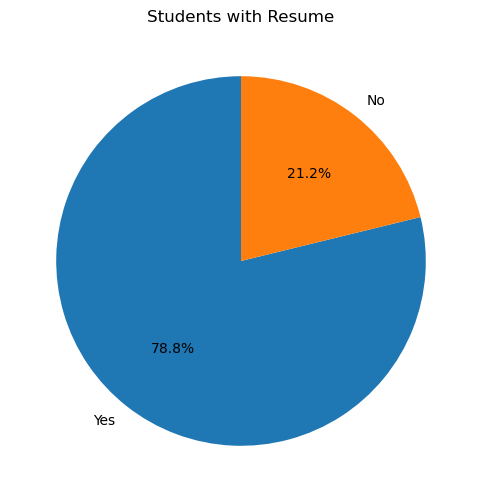

In [41]:
plt.figure(figsize=(6,6))

resume.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Students with Resume")

plt.ylabel("")

plt.show()

### Key Insights

- **78.8%** of students have already prepared a professional resume.
- Only **21.2%** of respondents have not yet created a resume.
- The high percentage of resume ownership indicates that most students have taken an important first step toward career preparation.

### Business Insight

Although the majority of students have a resume, institutions should encourage the remaining students to create professional resumes before applying for internships and full-time roles.

### Dashboard Recommendation

Display this analysis using a **Donut Chart** with percentage labels.

In [42]:
linkedin = df["has_linkedin"].value_counts()

linkedin

has_linkedin
Yes    65
No     20
Name: count, dtype: int64

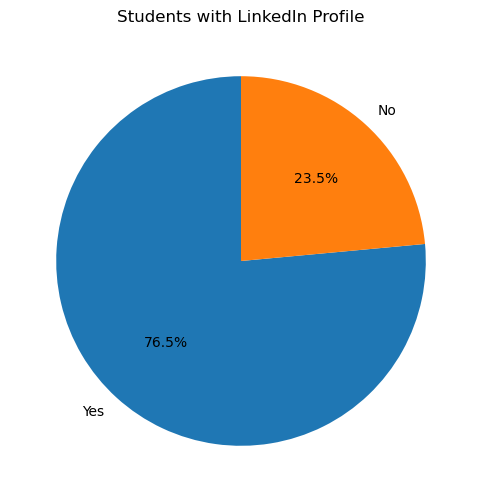

In [43]:
plt.figure(figsize=(6,6))

linkedin.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Students with LinkedIn Profile")

plt.ylabel("")

plt.show()

### Key Insights

- **76.5%** of students have a LinkedIn profile.
- Around **23.5%** of respondents are not yet present on LinkedIn.
- Most students recognize the importance of maintaining a professional online presence.

### Business Insight

While LinkedIn adoption is encouraging, institutions can further improve students' professional networking by promoting LinkedIn profile optimization workshops.

### Dashboard Recommendation

Use a **Donut Chart** to compare students with and without LinkedIn profiles.

In [ ]:
github = df["has_github"].value_counts()

github

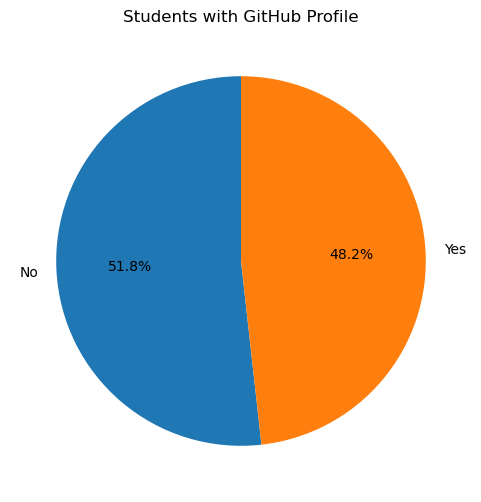

In [45]:
plt.figure(figsize=(6,6))

github.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Students with GitHub Profile")

plt.ylabel("")

plt.show()

### Key Insights

- **48.2%** of students have a GitHub profile.
- **51.8%** of students do not have a GitHub profile.
- GitHub adoption is significantly lower than resume and LinkedIn usage.

### Business Insight

The relatively low GitHub adoption suggests that many students have not yet developed an online technical portfolio, which is particularly important for software development and data-related careers.

### Dashboard Recommendation

Display this comparison using a **Donut Chart** highlighting GitHub adoption among students.

In [52]:
certification_order = [
    "0",
    "1-2",
    "3-5",
    "More than 5"
]

certification_count = (
    df["certification_count"]
    .value_counts()
    .reindex(certification_order)
)

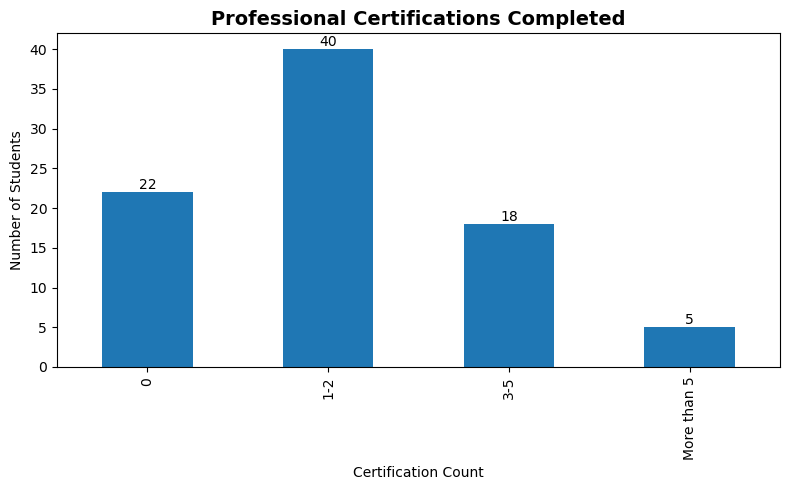

In [53]:
plt.figure(figsize=(8,5))

ax = certification_count.plot(kind="bar")

plt.title("Professional Certifications Completed", fontsize=14, fontweight="bold")
plt.xlabel("Certification Count")
plt.ylabel("Number of Students")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

### Key Insights

- The largest group of students (**40**) has completed **1–2 professional certifications**.
- **22 students** have not completed any certification.
- **18 students** have completed **3–5 certifications**, demonstrating strong commitment to continuous learning.
- Only **5 students** have completed **more than five certifications**.

### Business Insight

Most students have begun acquiring industry certifications, but there remains an opportunity to encourage students without certifications to pursue skill-based credentials that improve employability.

### Dashboard Recommendation

Use a **Bar Chart** sorted according to certification categories.

In [48]:
project_count = (
    df["project_count"]
    .value_counts()
)

project_count

project_count
1-2            37
3-5            26
0              17
More than 5     5
Name: count, dtype: int64

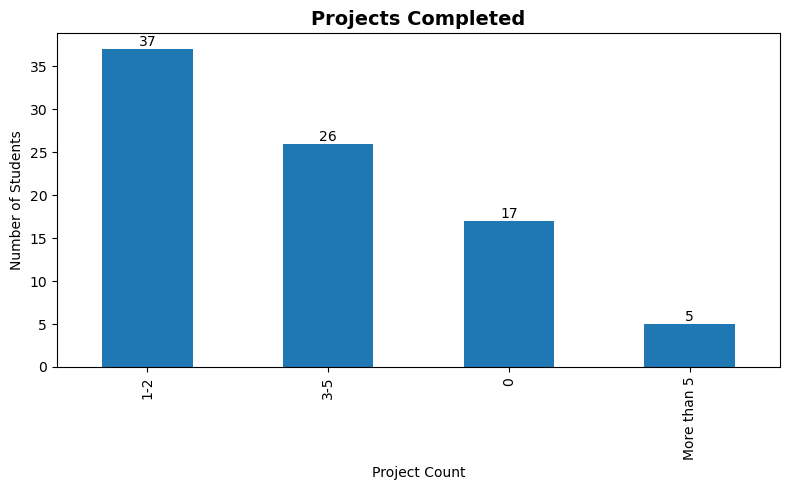

In [49]:
plt.figure(figsize=(8,5))

ax = project_count.plot(kind="bar")

plt.title("Projects Completed", fontsize=14, fontweight="bold")
plt.xlabel("Project Count")
plt.ylabel("Number of Students")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

### Key Insights

- The majority of students (**37**) have completed **1–2 projects**.
- **26 students** have completed **3–5 projects**, indicating practical learning experience.
- **17 students** have not completed any project.
- Only **5 students** have completed **more than five projects**.

### Business Insight

Project-based learning is reasonably common among respondents; however, a notable proportion of students still lack practical project experience. Encouraging hands-on projects can strengthen technical skills and improve employability.

### Dashboard Recommendation

Visualize project distribution using a **Bar Chart** ordered by project count categories.

# Section 5: Job Readiness Analysis

## Business Objective

Job readiness reflects how prepared students are to secure internships or full-time employment.

This section evaluates students' job search activities, interview experience, confidence in obtaining employment, and salary expectations.

The findings provide insights into students' employability and career preparedness.

## Business Question 1

### How many jobs have students applied for?

The number of job applications submitted reflects students' engagement with the job market.

This analysis helps understand whether students are actively seeking employment opportunities.

In [55]:
job_application_order = [
    "0",
    "1-20",
    "21-50",
    "51-100",
    "More than 100"
]

job_applications = (
    df["job_applications"]
    .value_counts()
    .reindex(job_application_order)
)

job_applications

job_applications
0                21
1-20             44
21-50            11
51-100            3
More than 100     6
Name: count, dtype: int64

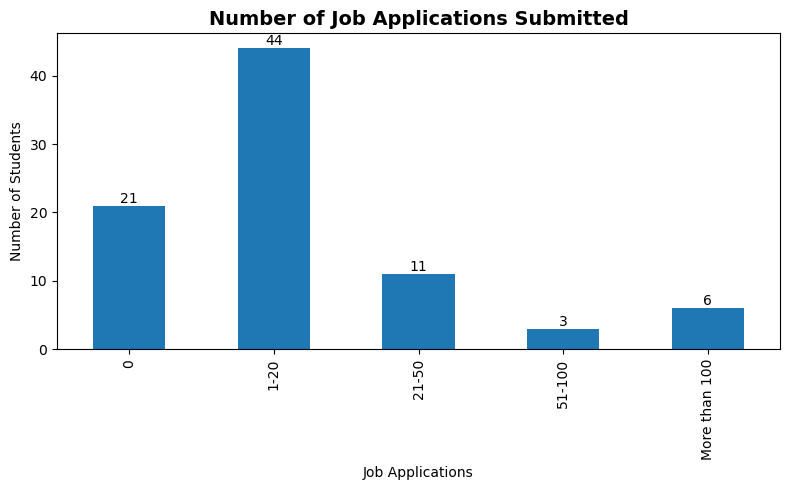

In [56]:
plt.figure(figsize=(8,5))

ax = job_applications.plot(kind="bar")

plt.title("Number of Job Applications Submitted", fontsize=14, fontweight="bold")
plt.xlabel("Job Applications")
plt.ylabel("Number of Students")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

In [57]:
interview_order = [
    "0",
    "1-2",
    "3-5",
    "More than 5"
]

interviews = (
    df["interview_count"]
    .value_counts()
    .reindex(interview_order)
)

interviews

interview_count
0              27
1-2            31
3-5            21
More than 5     6
Name: count, dtype: int64

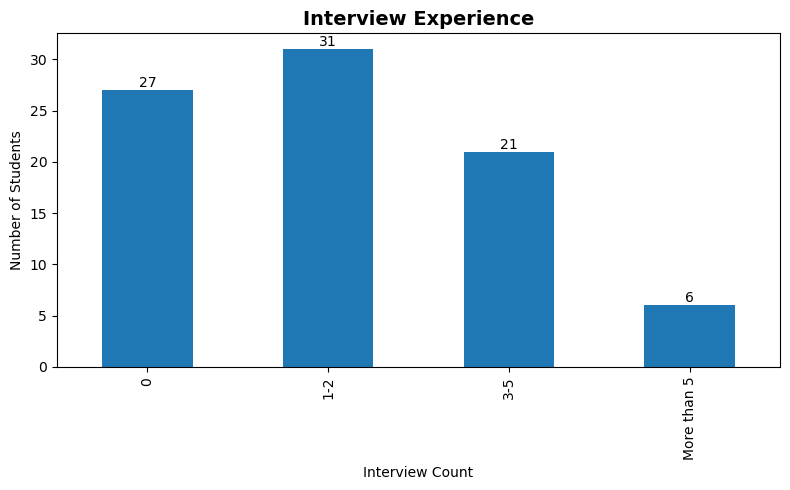

In [58]:
plt.figure(figsize=(8,5))

ax = interviews.plot(kind="bar")

plt.title("Interview Experience", fontsize=14, fontweight="bold")
plt.xlabel("Interview Count")
plt.ylabel("Number of Students")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

In [59]:
df["job_confidence"].value_counts()

job_confidence
4    26
3    23
5    19
1    11
2     6
Name: count, dtype: int64

In [60]:
job_confidence_order = [1, 2, 3, 4, 5]

job_confidence = (
    df["job_confidence"]
    .value_counts()
    .reindex(job_confidence_order)
)

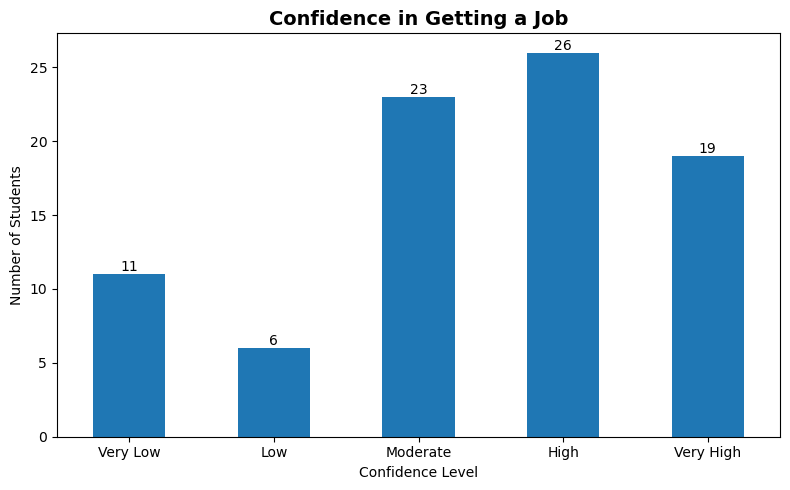

In [61]:
plt.figure(figsize=(8,5))

ax = job_confidence.plot(kind="bar")

plt.title("Confidence in Getting a Job", fontsize=14, fontweight="bold")
plt.xlabel("Confidence Level")
plt.ylabel("Number of Students")

plt.xticks(
    ticks=range(5),
    labels=[
        "Very Low",
        "Low",
        "Moderate",
        "High",
        "Very High"
    ],
    rotation=0
)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

In [64]:
expected_salary = df["expected_salary"].value_counts()

expected_salary

expected_salary
₹5–8 LPA         28
₹3–5 LPA         25
₹8–12 LPA        16
Above ₹12 LPA    12
Below ₹3 LPA      4
Name: count, dtype: int64

In [65]:
salary_order = [
    "Below ₹3 LPA",
    "₹3–5 LPA",
    "₹5–8 LPA",
    "₹8–12 LPA",
    "Above ₹12 LPA"
]

expected_salary = (
    df["expected_salary"]
    .value_counts()
    .reindex(salary_order)
)

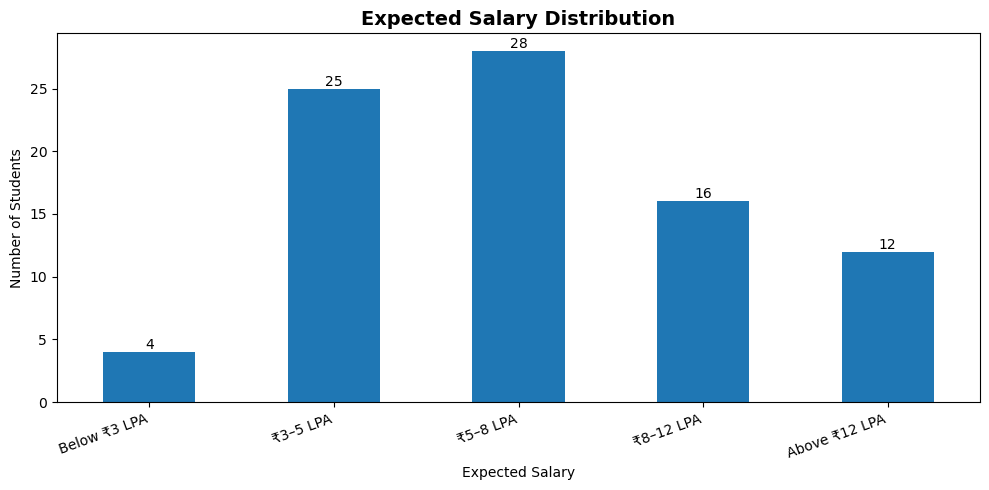

In [66]:
plt.figure(figsize=(10,5))

ax = expected_salary.plot(kind="bar")

plt.title("Expected Salary Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Expected Salary")
plt.ylabel("Number of Students")

plt.xticks(rotation=20, ha="right")

# Add value labels
for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

# Section 6: Career Goals & Challenges Analysis

## Business Objective

Career aspirations and challenges influence students' learning priorities and career preparation strategies.

This section explores students' career goals, the obstacles they face while preparing for their careers, the areas they wish to improve, and their overall satisfaction with their career preparation.

The insights will help identify common challenges and opportunities for improving students' employability.

## Business Question 1

### What career paths do students aspire to pursue?

Understanding students' career goals helps identify their professional interests and future aspirations.

In [67]:
career_goal = df["career_goal"].value_counts()

career_goal

career_goal
Data Analyst             22
AI / Machine Learning    17
Other                    11
Higher Studies            7
Government Jobs           6
Web Developer             5
Software Developer        5
Business Analyst          5
Digital Marketing         4
Cybersecurity             3
Name: count, dtype: int64

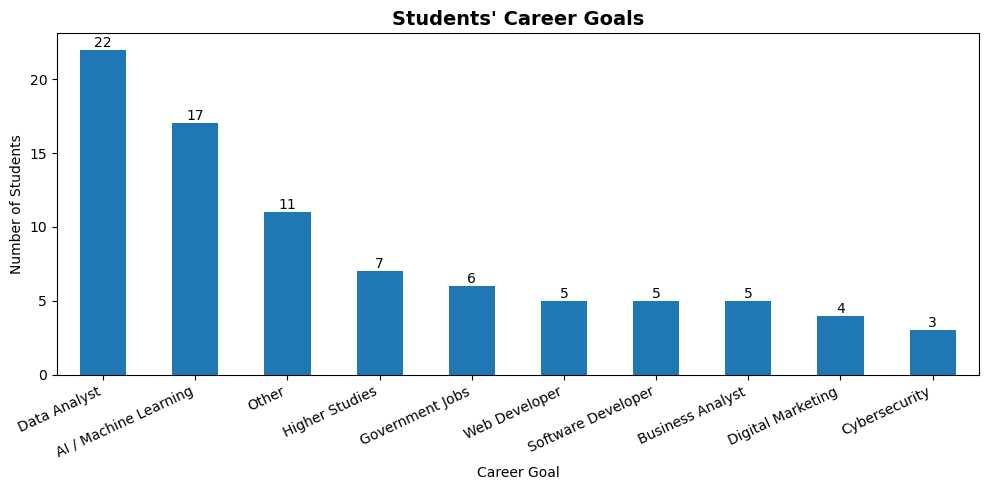

In [68]:
plt.figure(figsize=(10,5))

ax = career_goal.plot(kind="bar")

plt.title("Students' Career Goals", fontsize=14, fontweight="bold")
plt.xlabel("Career Goal")
plt.ylabel("Number of Students")

plt.xticks(rotation=25, ha="right")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

## Business Question 2

### What is the biggest challenge in students' career preparation?

Identifying common challenges helps understand the barriers that prevent students from becoming job-ready.

In [69]:
biggest_challenge = df["biggest_challenge"].value_counts()

biggest_challenge

biggest_challenge
Communication Skills         20
Lack of Technical Skills     18
Limited Job Opportunities    15
Lack of Experience           15
Interview Preparation         6
Lack of Projects              6
Other                         3
Resume Preparation            2
Name: count, dtype: int64

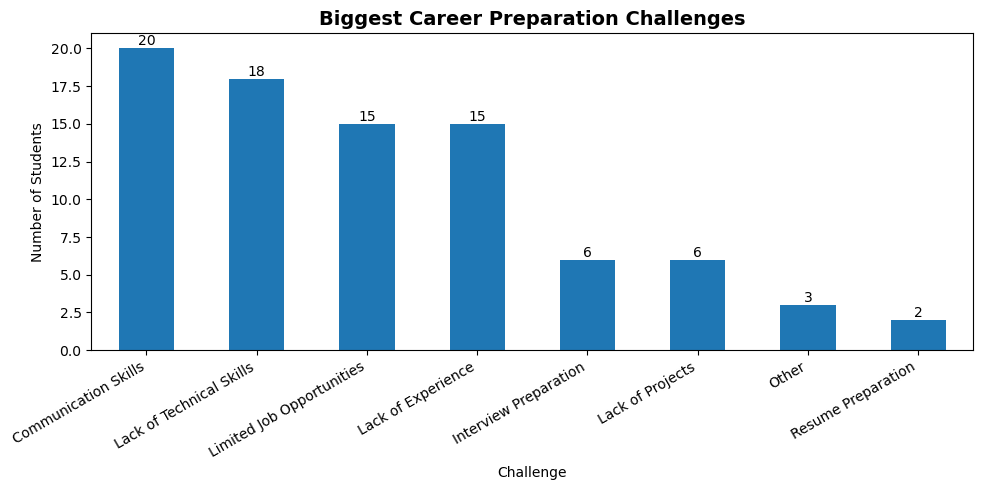

In [70]:
plt.figure(figsize=(10,5))

ax = biggest_challenge.plot(kind="bar")

plt.title("Biggest Career Preparation Challenges", fontsize=14, fontweight="bold")
plt.xlabel("Challenge")
plt.ylabel("Number of Students")

plt.xticks(rotation=30, ha="right")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

## Business Question 3

### Which skill or area do students want to improve?

This analysis identifies the areas where students feel additional development is required before entering the workforce.

In [71]:
improvement_area = df["improvement_area"].value_counts()

improvement_area

improvement_area
Technical Skills         33
Communication Skills     23
Interview Preparation    11
Time Management           6
Networking                4
Personal Projects         4
Certifications            2
Resume Building           2
Name: count, dtype: int64

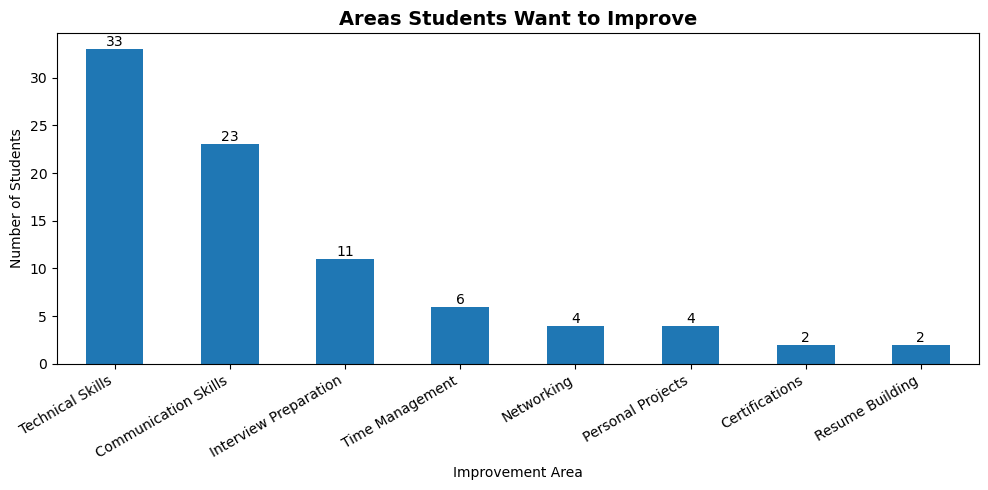

In [72]:
plt.figure(figsize=(10,5))

ax = improvement_area.plot(kind="bar")

plt.title("Areas Students Want to Improve", fontsize=14, fontweight="bold")
plt.xlabel("Improvement Area")
plt.ylabel("Number of Students")

plt.xticks(rotation=30, ha="right")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

In [73]:
satisfaction_order = [1, 2, 3, 4, 5]

career_satisfaction = (
    df["career_preparation_satisfaction"]
    .value_counts()
    .reindex(satisfaction_order)
)

career_satisfaction

career_preparation_satisfaction
1     6
2    13
3    38
4    18
5    10
Name: count, dtype: int64

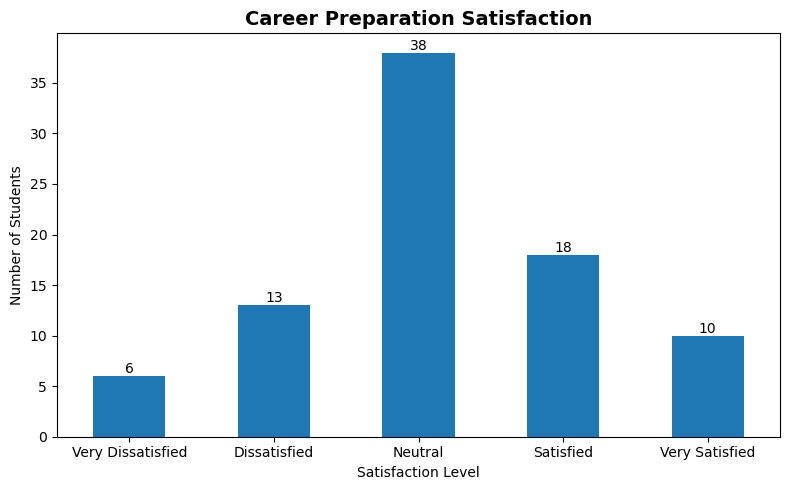

In [74]:
plt.figure(figsize=(8,5))

ax = career_satisfaction.plot(kind="bar")

plt.title("Career Preparation Satisfaction", fontsize=14, fontweight="bold")
plt.xlabel("Satisfaction Level")
plt.ylabel("Number of Students")

plt.xticks(
    ticks=range(5),
    labels=[
        "Very Dissatisfied",
        "Dissatisfied",
        "Neutral",
        "Satisfied",
        "Very Satisfied"
    ],
    rotation=0
)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

## Section Summary

This section examined students' career aspirations, the challenges they encounter during career preparation, the areas they wish to improve, and their satisfaction with their current level of preparation.

The findings provide valuable insights into students' career expectations and the support they need to improve their employability.

# Section 7: Relationship Analysis

## Business Objective

While individual distributions provide useful insights, understanding the relationships between variables helps uncover deeper patterns in student career readiness.

This section explores how technical skills, learning behaviour, projects, certifications, and professional profiles relate to employability indicators such as interview experience and job confidence.

These findings provide actionable insights for educators, career counselors, and students.

## Analysis 1

### Does completing more projects improve technical confidence?

Projects provide practical experience and help students apply theoretical knowledge.

This analysis examines whether students who complete more projects report higher technical confidence.

In [75]:
project_vs_confidence = pd.crosstab(
    df["project_count"],
    df["technical_confidence"]
)

project_vs_confidence

technical_confidence,1,2,3,4,5
project_count,,,,,
0,3,1,6,5,2
1-2,2,4,19,10,2
3-5,0,2,9,11,4
More than 5,0,0,1,4,0


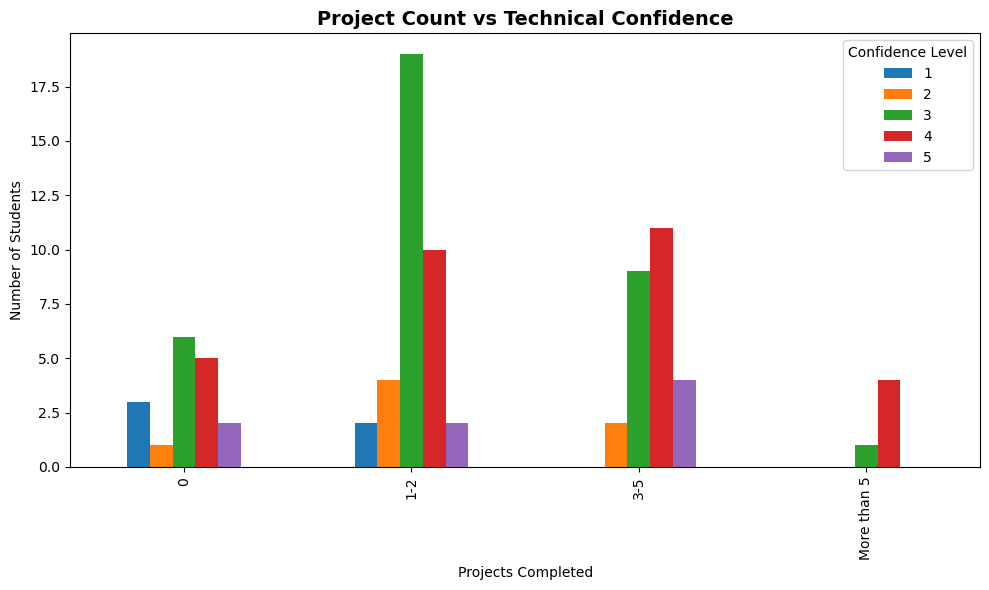

In [76]:
project_vs_confidence.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Project Count vs Technical Confidence", fontsize=14, fontweight="bold")

plt.xlabel("Projects Completed")
plt.ylabel("Number of Students")

plt.legend(title="Confidence Level")

plt.tight_layout()

plt.show()

## Analysis 2

### Do students with a GitHub profile report higher technical confidence?

GitHub serves as an online portfolio for technical work.

This analysis compares technical confidence between students who have a GitHub profile and those who do not.

In [77]:
github_vs_confidence = pd.crosstab(
    df["has_github"],
    df["technical_confidence"]
)

github_vs_confidence

technical_confidence,1,2,3,4,5
has_github,,,,,
No,3,5,17,12,7
Yes,2,2,18,18,1


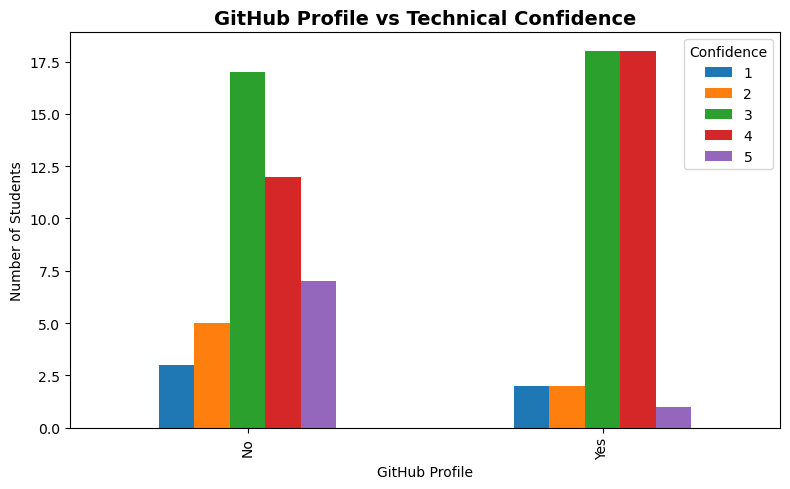

In [78]:
github_vs_confidence.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("GitHub Profile vs Technical Confidence", fontsize=14, fontweight="bold")

plt.xlabel("GitHub Profile")
plt.ylabel("Number of Students")

plt.legend(title="Confidence")

plt.tight_layout()

plt.show()

## Analysis 3

### Is there a relationship between certifications and job confidence?

Professional certifications improve technical knowledge and demonstrate continuous learning.

This analysis explores whether students with more certifications report higher confidence in getting a job.

In [79]:
certification_vs_job = pd.crosstab(
    df["certification_count"],
    df["job_confidence"]
)

certification_vs_job

job_confidence,1,2,3,4,5
certification_count,,,,,
0,5,2,6,5,4
1-2,5,1,13,13,8
3-5,1,2,4,5,6
More than 5,0,1,0,3,1


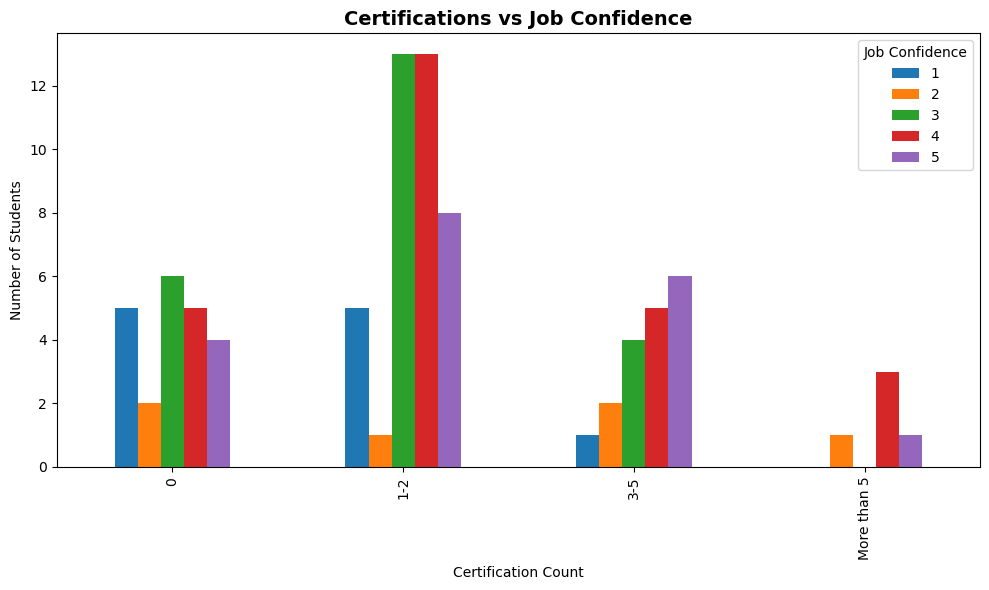

In [80]:
certification_vs_job.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Certifications vs Job Confidence", fontsize=14, fontweight="bold")

plt.xlabel("Certification Count")
plt.ylabel("Number of Students")

plt.legend(title="Job Confidence")

plt.tight_layout()

plt.show()

In [81]:
resume_vs_interview = pd.crosstab(
    df["has_resume"],
    df["interview_count"]
)

resume_vs_interview

interview_count,0,1-2,3-5,More than 5
has_resume,,,,
No,12,5,1,0
Yes,15,26,20,6


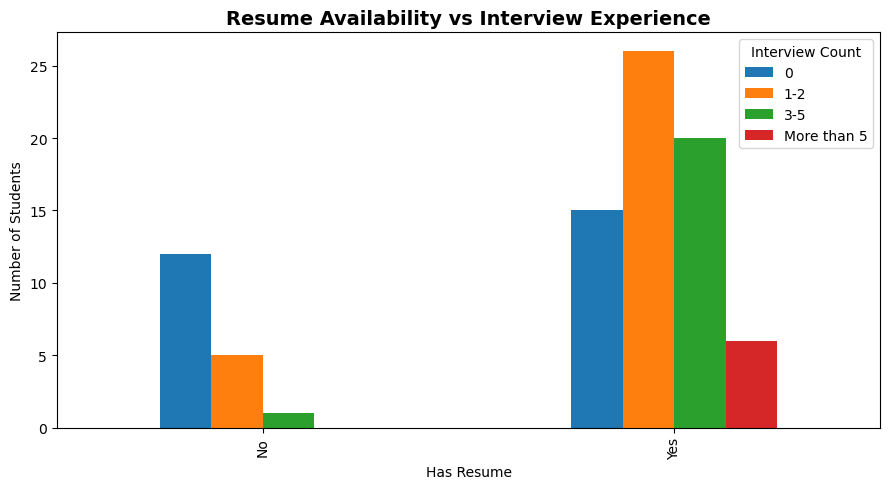

In [82]:
resume_vs_interview.plot(
    kind="bar",
    figsize=(9,5)
)

plt.title("Resume Availability vs Interview Experience", fontsize=14, fontweight="bold")

plt.xlabel("Has Resume")
plt.ylabel("Number of Students")

plt.legend(title="Interview Count")

plt.tight_layout()

plt.show()

In [83]:
learning_vs_confidence = pd.crosstab(
    df["daily_learning_hours"],
    df["technical_confidence"]
)

learning_vs_confidence

technical_confidence,1,2,3,4,5
daily_learning_hours,,,,,
1–2 hours,2,2,12,11,1
2–4 hours,1,2,7,12,2
4–6 hours,0,0,6,3,4
Less than 1 hour,2,3,9,2,1
More than 6 hours,0,0,1,2,0


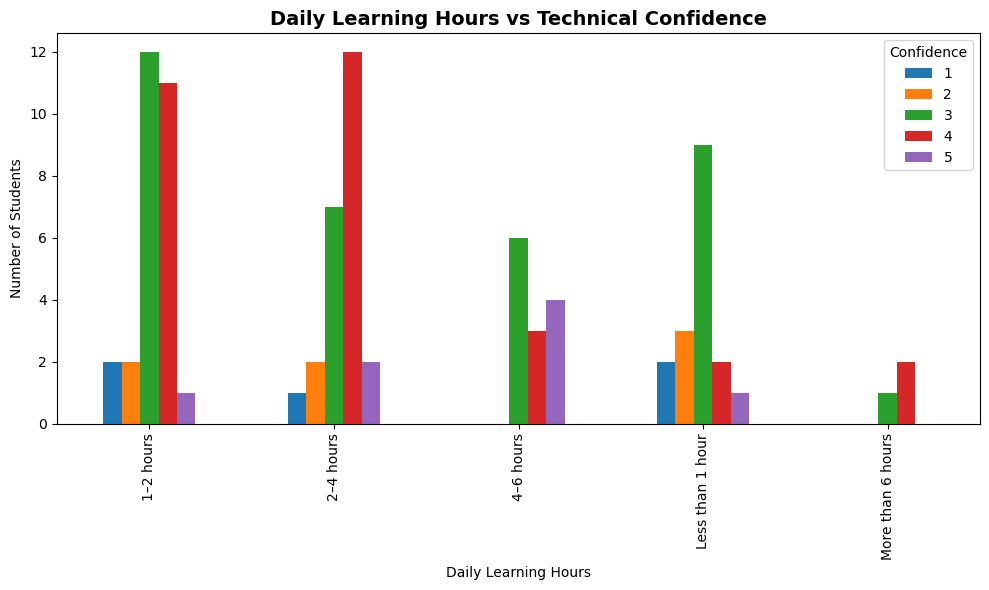

In [84]:
learning_vs_confidence.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Daily Learning Hours vs Technical Confidence", fontsize=14, fontweight="bold")

plt.xlabel("Daily Learning Hours")
plt.ylabel("Number of Students")

plt.legend(title="Confidence")

plt.tight_layout()

plt.show()

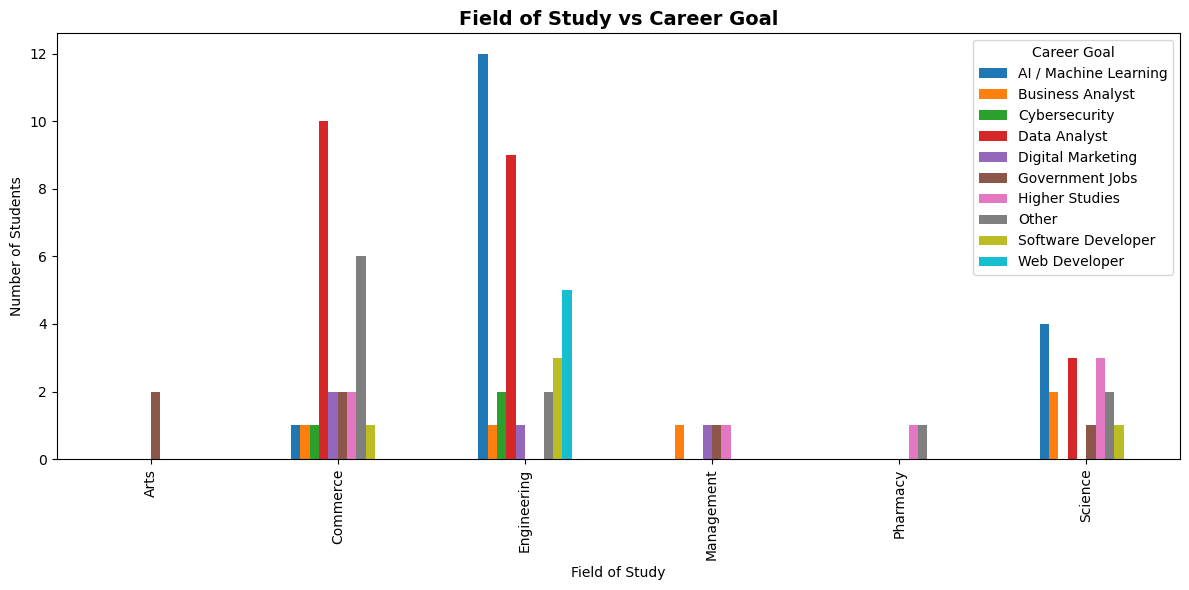

In [85]:
field_vs_goal = pd.crosstab(
    df["field_of_study"],
    df["career_goal"]
)

field_vs_goal.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Field of Study vs Career Goal", fontsize=14, fontweight="bold")

plt.xlabel("Field of Study")
plt.ylabel("Number of Students")

plt.legend(title="Career Goal")

plt.tight_layout()

plt.show()

# Section 8: Executive Summary & Recommendations

## Objective

This section summarizes the major findings from the exploratory data analysis and provides actionable recommendations based on the survey results.

The insights presented here can help students, educational institutions, placement cells, and training providers understand current career readiness levels and identify areas for improvement.

These findings also serve as the foundation for the Power BI dashboard and future decision-making.

## Key Findings

### 1. Student Demographics
- The survey received **85 responses** from students across multiple academic backgrounds.
- Most respondents were **Recent Graduates** and **Bachelor's Degree** students.
- Engineering and Commerce students formed the largest academic groups.
- The majority of responses were collected from Telangana.

---

### 2. Technical Skills
- Microsoft Excel, SQL, and Python emerged as the most common technical skills.
- Students also showed strong interest in Power BI, AI Tools, and Data Analysis.
- Online learning platforms are the primary source of technical skill development.

---

### 3. Learning Behaviour
- Most students rated their technical confidence as **Moderate**.
- A large proportion of students dedicate **1–2 hours daily** to learning new skills.

---

### 4. Career Readiness
- Most students have already created professional resumes.
- LinkedIn adoption is high among respondents.
- GitHub adoption remains comparatively lower.
- Most students have completed **1–2 certifications** and **1–2 personal or academic projects**.

---

### 5. Job Readiness
- Most respondents have begun applying for jobs.
- Interview experience remains limited for many students.
- Students generally report moderate confidence in securing employment.
- Salary expectations are concentrated around entry-level industry packages.

---

### 6. Career Goals & Challenges
- Students have clear career aspirations but continue to face challenges related to practical experience and industry readiness.
- Many respondents identified technical skill improvement and practical exposure as important priorities.

## Recommendations

Based on the survey findings, the following recommendations are suggested:

### For Students

- Build more hands-on projects to strengthen technical portfolios.
- Earn industry-recognized certifications in relevant technologies.
- Create and maintain professional LinkedIn and GitHub profiles.
- Apply consistently for internships and entry-level positions.
- Practice technical interviews and aptitude assessments regularly.

---

### For Educational Institutions

- Conduct regular resume-building and LinkedIn optimization workshops.
- Encourage project-based learning across academic programs.
- Organize hackathons, coding competitions, and industry interaction sessions.
- Increase internship opportunities through industry collaborations.
- Provide structured career guidance and placement preparation programs.

---

### For Placement Cells

- Identify students with lower career readiness and provide targeted support.
- Offer mock interviews and career counseling sessions.
- Promote certification programs aligned with current industry demands.

## Conclusion

The Student Career & Employability Survey provides valuable insights into students' technical skills, learning behaviour, career readiness, and employment aspirations.

The analysis indicates that while many students have taken positive steps such as building resumes, obtaining certifications, and learning in-demand technologies, there are still opportunities to improve practical project experience, GitHub adoption, interview preparation, and overall job readiness.

The findings from this study can assist educational institutions, placement teams, and students in making informed decisions to improve employability outcomes.

The insights generated in this notebook will be further explored through an interactive Power BI dashboard to enable dynamic data visualization and stakeholder decision-making.

## Limitations

- The survey consists of **85 responses**, which may not fully represent the broader student population.
- The majority of respondents are from Telangana, resulting in a regional concentration.
- Responses are self-reported and may be influenced by individual perceptions.
- The findings represent the survey period only and may change over time as students gain additional skills and experience.

## Future Scope

Future work can expand this study by:

- Increasing the number of survey responses across multiple states.
- Including students from additional universities and disciplines.
- Performing predictive analysis using Machine Learning techniques.
- Developing an interactive Power BI dashboard for real-time exploration.
- Conducting yearly surveys to analyze career readiness trends over time.